In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

In [4]:
%matplotlib inline

In [5]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [6]:
from sklearn.ensemble import RandomForestRegressor

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
import numpy as np

In [9]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/4. Scaling/Scaling(One-Hot).csv")

In [10]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Spider-Man: Mysterio's Menace,0.701367,1.0,0.741379,0.000000,0.280702,0.017544,2001,0,0,...,1,0,2000,0.704918,0.262295,0.000000,0.016393,0,High,2
1,Tomb Raider Chronicles,0.701367,1.0,0.586207,0.000000,0.403509,0.070175,2000,0,0,...,0,0,2000,0.557377,0.377049,0.000000,0.065574,0,High,2
2,Tony Hawk: RIDE,0.402299,1.0,0.655172,0.000000,0.263158,0.140351,2009,0,0,...,0,0,2000,0.622951,0.245902,0.000000,0.131148,0,Medium,1
3,Advance Wars: Days of Ruin,0.850575,1.0,0.741379,0.000000,0.228070,0.087719,2008,0,0,...,0,0,2000,0.704918,0.213115,0.000000,0.081967,0,High,2
4,New Play Control! Pikmin 2,0.885057,1.0,0.189655,0.557377,0.228070,0.035088,2012,0,0,...,0,0,2010,0.180328,0.213115,0.557377,0.032787,0,High,2


In [11]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
                         ...   
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
Length: 133, dtype: object

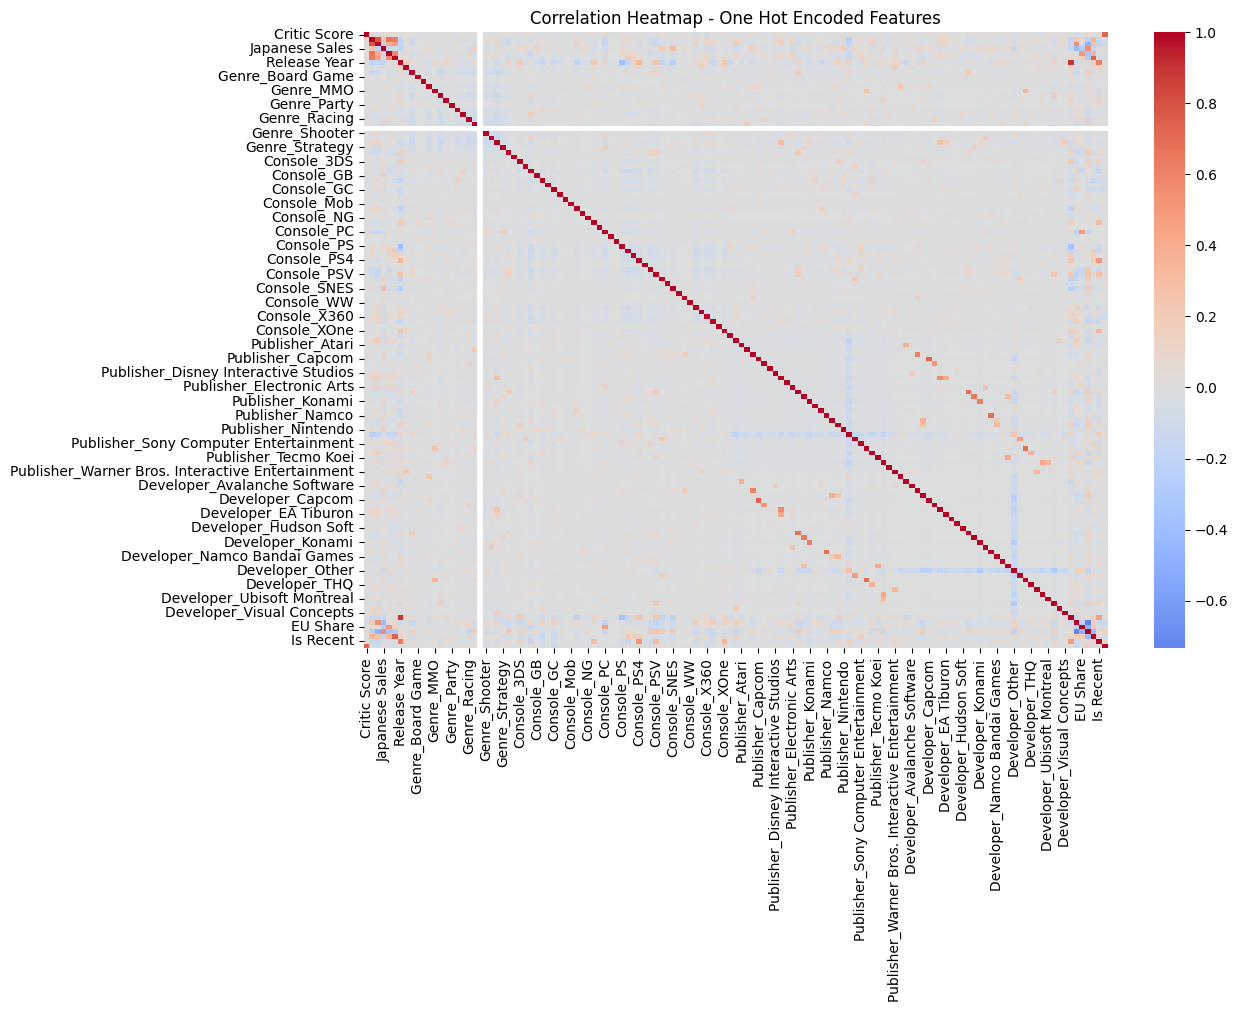

In [12]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [13]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 130
After VarianceThreshold: 112


Top MI features:
 Other Share             1.830187
NA Share                1.576286
EU Share                1.378624
North American Sales    0.906272
Japanese Sales          0.649920
Other Sales             0.512370
EU Sales                0.441177
JP Share                0.219159
Release Year            0.059061
Publisher_Other         0.045450
Decade                  0.027739
Critic Score            0.020994
Publisher_THQ           0.016534
Publisher_Nintendo      0.014637
Is Recent               0.014626
dtype: float64


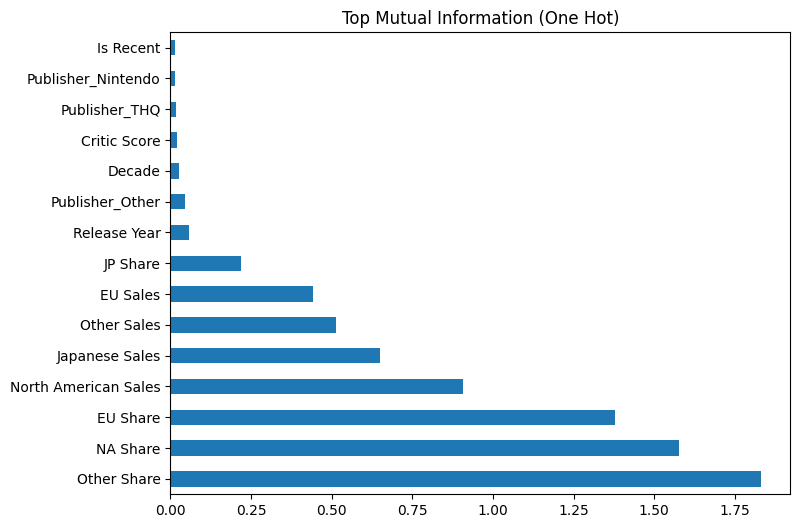

In [14]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

Top RF features:
 North American Sales    0.612375
Japanese Sales          0.146125
Other Sales             0.124404
EU Sales                0.051032
NA Share                0.045003
Other Share             0.014119
EU Share                0.002944
JP Share                0.002714
Release Year            0.000236
Critic Score            0.000127
Decade                  0.000042
Genre_Misc              0.000040
Genre_Sports            0.000040
Publisher_THQ           0.000038
Console_PS3             0.000035
dtype: float64


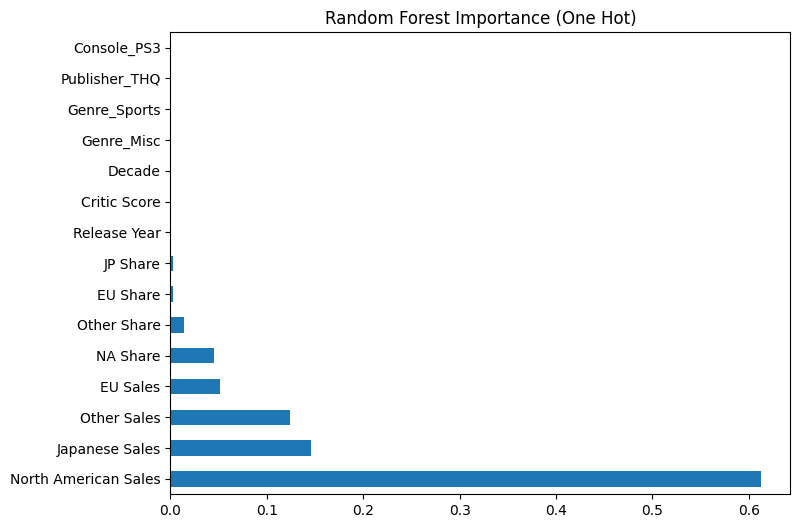

In [17]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [16]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/5. Feature Selection/Feature Selection(1-hot).csv", index=False)